Visualize spectrograms of trimmed audio

Found 112 total files
Visualizing: SL43 Trial 1_trim.WAV

Processing: SL43 Trial 1_trim.WAV
  Duration: 60.00 seconds
  ✓ Spectrogram created successfully


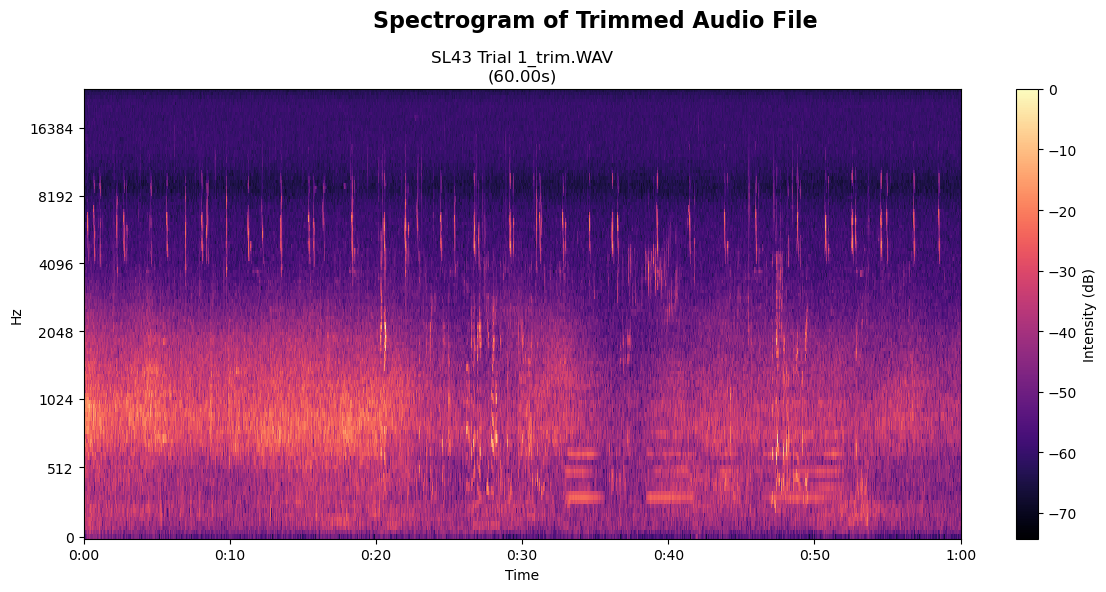


=== Spectrogram visualization complete! ===
Look at the spectrogram above to see:
  - Time on the X-axis (should be ~60 seconds)
  - Frequency on the Y-axis (how high/low the sounds are)
  - Color intensity (brighter = louder/more energy)


In [5]:
# === VISUALIZE SPECTROGRAMS FROM TRIMMED AUDIO ===
# This code will load a few audio files and display their spectrograms
# A spectrogram is a visual representation of sound over time
# It shows frequency (how high/low the sound is) on the y-axis and time on the x-axis

import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# === SET UP ===
# Tell Python where our trimmed audio files are
trimmed_audio_dir = "/mnt/class_data/Shelby/One_Minute_Audio"

# Get a list of audio files to visualize
# We'll just look at the first file
audio_files = [f for f in os.listdir(trimmed_audio_dir) if f.endswith('.WAV') or f.endswith('.wav')]
file_to_visualize = audio_files[1]  # Take only the first file

print(f"Found {len(audio_files)} total files")
print(f"Visualizing: {file_to_visualize}")

# === CREATE SPECTROGRAM ===
# Create a single plot to show one spectrogram
fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Spectrogram of Trimmed Audio File', fontsize=16, fontweight='bold')

# Process the audio file
print(f"\nProcessing: {file_to_visualize}")

try:
    # Create the full path to the audio file
    audio_path = os.path.join(trimmed_audio_dir, file_to_visualize)
    
    # Load the audio file
    # y = the audio data (sound waves as numbers)
    # sr = sample rate (how many samples per second, usually 44100 or 256000)
    y, sr = librosa.load(audio_path, sr=None)

        # Trim to first 15 seconds
    duration_limit = 15  # seconds
    samples_to_keep = sr * duration_limit
    y = y[:int(samples_to_keep)]
    
    # Calculate how long the audio is in seconds
    duration = librosa.get_duration(y=y, sr=sr)
    print(f"  Duration: {duration:.2f} seconds")
    
    # Create a spectrogram from the audio
    # A spectrogram breaks the audio into tiny pieces and analyzes each piece
    # S = spectrogram (magnitude of frequencies over time)
    # S_db = spectrogram in decibels (a better scale for human hearing)
    S = librosa.feature.melspectrogram(y=y, sr=sr)
    S_db = librosa.power_to_db(S, ref=np.max)
    
    # Display the spectrogram on the plot
    img = librosa.display.specshow(
        S_db,
        sr=sr,
        ax=ax,
        x_axis='time',  # Show time on x-axis
        y_axis='mel'    # Show frequency (mel scale) on y-axis
    )
    
    # Add a label and title to the plot
    ax.set_title(f'{file_to_visualize}\n({duration:.2f}s)', fontsize=12)
    
    # Add a colorbar to show what the colors mean (intensity of sound)
    plt.colorbar(img, ax=ax, label='Intensity (dB)')
    
    print(f"  ✓ Spectrogram created successfully")
    
except Exception as e:
    print(f"  ✗ Error creating spectrogram: {str(e)}")
    ax.text(0.5, 0.5, f'Error: {str(e)}', ha='center', va='center')

# Adjust the layout so nothing overlaps
plt.tight_layout()

# Display the plot
plt.show()

print("\n=== Spectrogram visualization complete! ===")
print("Look at the spectrogram above to see:")
print("  - Time on the X-axis (should be ~60 seconds)")
print("  - Frequency on the Y-axis (how high/low the sounds are)")
print("  - Color intensity (brighter = louder/more energy)")


Draw bounding boxes

Loaded 6238 annotations from CSV

Looking for: SL07 Trial 2_trim.WAV
Exact match for 'SL07 Trial 2_trim.WAV': 208 annotations
Audio duration: 5.00 seconds
Sample rate: 48000 Hz

Spectrogram axis limits after display:
  X-axis (time): (np.float64(-0.0026666666666666666), np.float64(4.989333333333333))
  Y-axis (Hz): (np.float64(0.0), np.float64(12000.0))

Drawing 208 bounding boxes...


All annotations min/max:
  Time (seconds): 0.19 - 59.70
  Freq (Hz): 59 - 23916
Annotation 1:
  Time: 0.19-0.28s
  Freq (Hz): 801-16661
Annotation 2:
  Time: 1.03-1.11s
  Freq (Hz): 2151-4682
Annotation 3:
  Time: 1.69-1.77s
  Freq (Hz): 506-15480
Annotation 4:
  Time: 2.27-2.35s
  Freq (Hz): 1265-17757
Annotation 5:
  Time: 2.49-2.58s
  Freq (Hz): 928-18095
Annotation 6:
  Time: 2.98-3.07s
  Freq (Hz): 801-17547
Annotation 7:
  Time: 3.14-3.22s
  Freq (Hz): 970-22102
Annotation 8:
  Time: 3.31-3.40s
  Freq (Hz): 886-22524
Annotation 9:
  Time: 3.47-3.55s
  Freq (Hz): 759-23241
Annotation 10:
  Time: 3.6

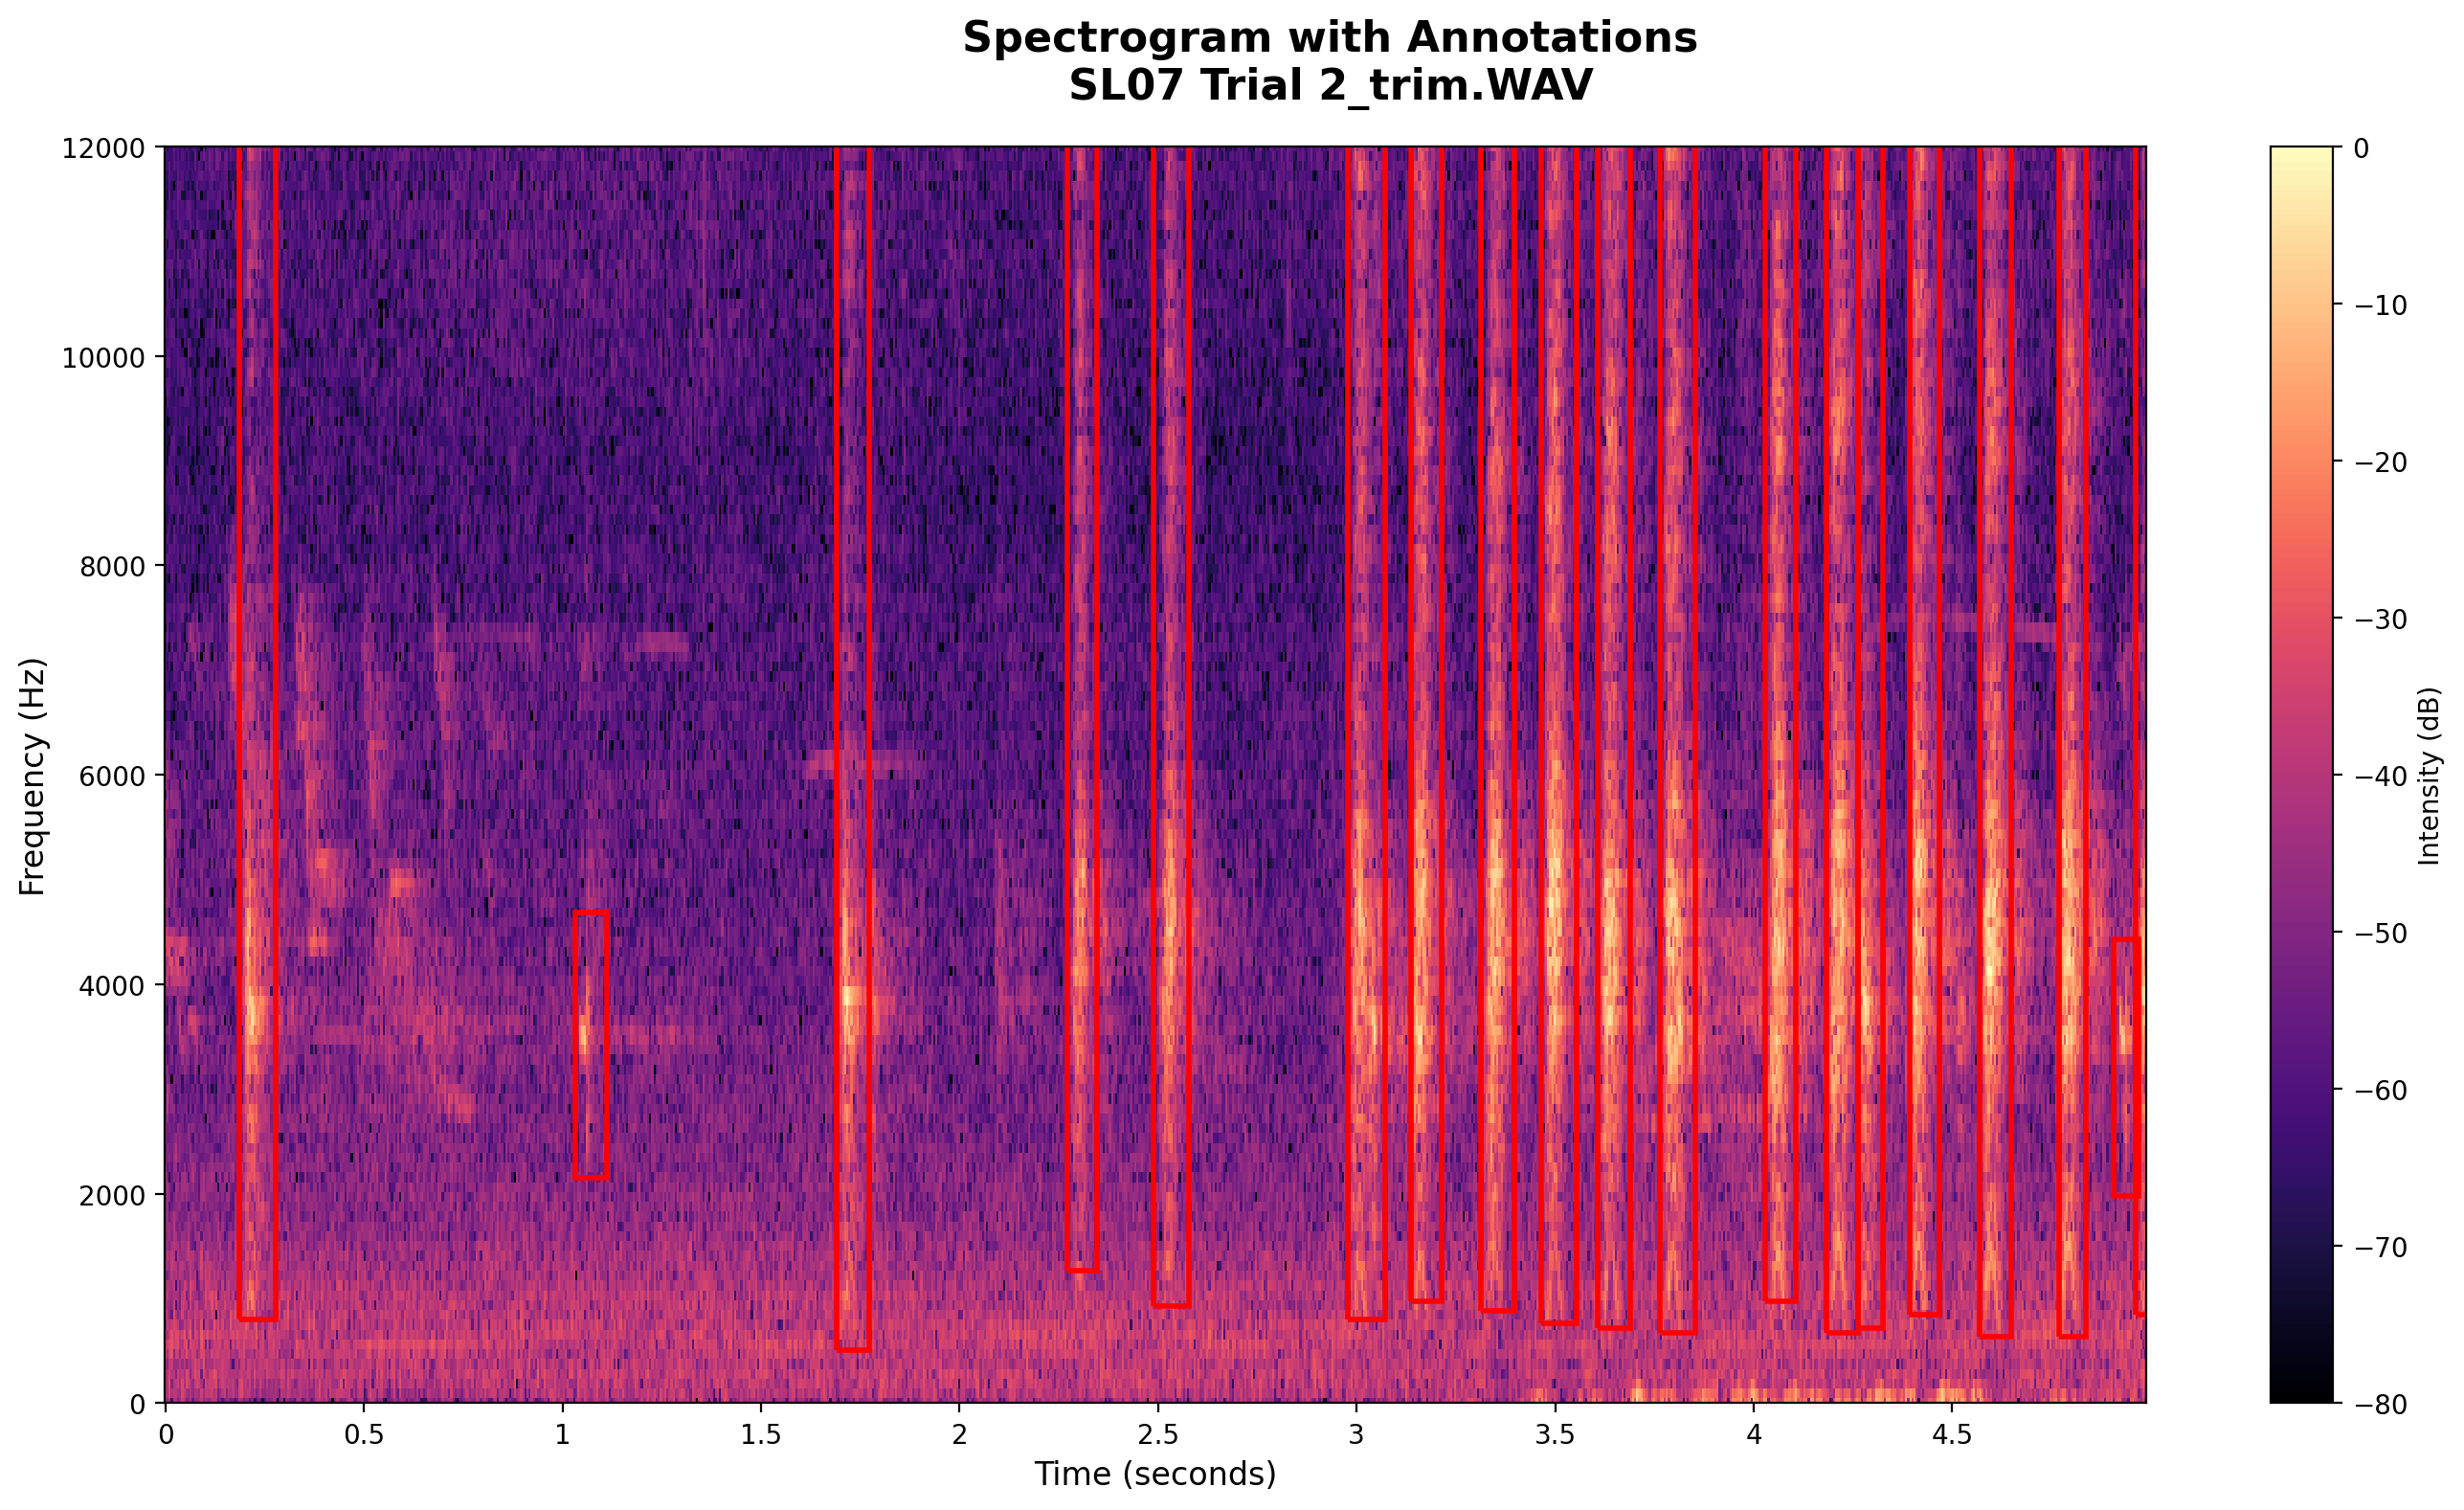


=== Visualization complete! ===


In [24]:
# === VISUALIZE SPECTROGRAMS WITH BOUNDING BOXES FROM CSV ANNOTATIONS ===
# Matches Raven Pro settings:
# - Hann window
# - Window size: 512 samples
# - DFT size (n_fft): 512 samples
# - Overlap: 50%  -> hop_length: 256 samples
# - Linear frequency axis (not mel)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import librosa
import librosa.display

# === LOAD THE CSV FILE ===
csv_path = "/home/Shelby/blackbird_calls/Dataset_processing/Datasets/cv4e_calls_channel1.csv"
annotations_df = pd.read_csv(csv_path)
print(f"Loaded {len(annotations_df)} annotations from CSV")

current_wav_fname = file_to_visualize
print(f"\nLooking for: {current_wav_fname}")

matching_annotations = annotations_df[annotations_df["wav_fname"] == current_wav_fname]
print(f"Exact match for '{current_wav_fname}': {len(matching_annotations)} annotations")

if len(matching_annotations) == 0:
    print("\nNo exact match found. Trying case-insensitive match...")
    matching_annotations = annotations_df[annotations_df["wav_fname"].str.lower() == current_wav_fname.lower()]
    print(f"Case-insensitive match: {len(matching_annotations)} annotations")

if len(matching_annotations) == 0:
    print("\nWARNING: Still no annotations found!")
else:
    fig, ax = plt.subplots(figsize=(14, 8), dpi=200)
    fig.suptitle(f"Spectrogram with Annotations\n{file_to_visualize}", fontsize=16, fontweight="bold")

    try:
        audio_path = os.path.join(trimmed_audio_dir, file_to_visualize)

        # Load audio without resampling; use channel 1 only if stereo
        y, sr = librosa.load(audio_path, sr=None, mono=False)
        if y.ndim > 1:
            y = y[0]

        # Trim to first 5 seconds (matching your previous cell)
        duration_limit = 5
        y = y[: int(sr * duration_limit)]

        duration = librosa.get_duration(y=y, sr=sr)
        print(f"Audio duration: {duration:.2f} seconds")
        print(f"Sample rate: {sr} Hz\n")

        # --- Raven-matched STFT settings ---
        n_fft = 512
        win_length = 512
        hop_length = 256
        window = "hann"

        # Linear-frequency STFT (not mel)
        D = librosa.stft(
            y,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=win_length,
            window=window,
            center=False,
        )
        S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

        # Display the spectrogram (linear frequency axis)
        img = librosa.display.specshow(
            S_db,
            sr=sr,
            hop_length=hop_length,
            ax=ax,
            x_axis="time",
            y_axis="linear",
            fmin=2000,
            fmax=8000
        )

        # Optionally zoom frequency view to match your typical Raven display
        # (Change/remove as desired)
        ax.set_ylim(0, 12000)

        print("Spectrogram axis limits after display:")
        print(f"  X-axis (time): {ax.get_xlim()}")
        print(f"  Y-axis (Hz): {ax.get_ylim()}\n")

        # === DRAW BOUNDING BOXES FROM ANNOTATIONS ===
        print(f"Drawing {len(matching_annotations)} bounding boxes...\n")
        print("\nAll annotations min/max:")
        print(f"  Time (seconds): {matching_annotations['begin_time_s'].min():.2f} - {matching_annotations['end_time_s'].max():.2f}")
        print(f"  Freq (Hz): {matching_annotations['low_freq_hz'].min():.0f} - {matching_annotations['high_freq_hz'].max():.0f}")

        box_count = 0
        for idx, (_, row) in enumerate(matching_annotations.iterrows()):
            time_start = float(row["begin_time_s"])
            time_end = float(row["end_time_s"])
            freq_low_hz = float(row["low_freq_hz"])
            freq_high_hz = float(row["high_freq_hz"])

            if idx < 10:
                print(f"Annotation {idx + 1}:")
                print(f"  Time: {time_start:.2f}-{time_end:.2f}s")
                print(f"  Freq (Hz): {freq_low_hz:.0f}-{freq_high_hz:.0f}")

            rect = Rectangle(
                (time_start, freq_low_hz),
                time_end - time_start,
                freq_high_hz - freq_low_hz,
                linewidth=2,
                edgecolor="red",
                facecolor="none",
            )
            ax.add_patch(rect)
            box_count += 1

        print(f"\nAdded {box_count} rectangles to the plot")

        plt.colorbar(img, ax=ax, label="Intensity (dB)")
        ax.set_xlabel("Time (seconds)", fontsize=12)
        ax.set_ylabel("Frequency (Hz)", fontsize=12)

        print(f"✓ Spectrogram with {len(matching_annotations)} annotations created successfully")

    except Exception as e:
        print(f"✗ Error: {str(e)}")
        import traceback

        traceback.print_exc()

    plt.tight_layout()
    plt.show()

    print("\n=== Visualization complete! ===")


Signature:
librosa.display.specshow(
    data: 'np.ndarray',
    *,
    x_coords: 'Optional[np.ndarray]' = None,
    y_coords: 'Optional[np.ndarray]' = None,
    x_axis: 'Optional[str]' = None,
    y_axis: 'Optional[str]' = None,
    sr: 'float' = 22050,
    hop_length: 'int' = 512,
    n_fft: 'Optional[int]' = None,
    win_length: 'Optional[int]' = None,
    fmin: 'Optional[float]' = None,
    fmax: 'Optional[float]' = None,
    tempo_min: 'Optional[float]' = 16,
    tempo_max: 'Optional[float]' = 480,
    tuning: 'float' = 0.0,
    bins_per_octave: 'int' = 12,
    key: 'str' = 'C:maj',
    Sa: 'Optional[Union[float, int]]' = None,
    mela: 'Optional[Union[str, int]]' = None,
    thaat: 'Optional[str]' = None,
    auto_aspect: 'bool' = True,
    htk: 'bool' = False,
    unicode: 'bool' = True,
    intervals: 'Optional[Union[str, np.ndarray]]' = None,
    unison: 'Optional[str]' = None,
    ax: 'Optional[mplaxes.Axes]' = None,
    **kwargs: 'Any',
) -> 'QuadMesh'
Docstring:
Display a

In [ ]:
librosa.display.specshow(data, win_length=512)

Signature:
librosa.display.specshow(
    data: 'np.ndarray',
    *,
    x_coords: 'Optional[np.ndarray]' = None,
    y_coords: 'Optional[np.ndarray]' = None,
    x_axis: 'Optional[str]' = None,
    y_axis: 'Optional[str]' = None,
    sr: 'float' = 22050,
    hop_length: 'int' = 512,
    n_fft: 'Optional[int]' = None,
    win_length: 'Optional[int]' = None,
    fmin: 'Optional[float]' = None,
    fmax: 'Optional[float]' = None,
    tempo_min: 'Optional[float]' = 16,
    tempo_max: 'Optional[float]' = 480,
    tuning: 'float' = 0.0,
    bins_per_octave: 'int' = 12,
    key: 'str' = 'C:maj',
    Sa: 'Optional[Union[float, int]]' = None,
    mela: 'Optional[Union[str, int]]' = None,
    thaat: 'Optional[str]' = None,
    auto_aspect: 'bool' = True,
    htk: 'bool' = False,
    unicode: 'bool' = True,
    intervals: 'Optional[Union[str, np.ndarray]]' = None,
    unison: 'Optional[str]' = None,
    ax: 'Optional[mplaxes.Axes]' = None,
    **kwargs: 'Any',
) -> 'QuadMesh'
Docstring:
Display a